<a href="https://colab.research.google.com/github/Max48732/-/blob/main/CodeLab5_Classification_Pipelined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Технологии обработки больших данных

## Занятие 5. Машинное обучение в PySpark. Классификация

1. Понятие энтропии Шеннона и поставновка задачи классификации
2. Классификация с помощью решающих деревьев в pyspark
3. Метрики качества
4. Работа со строковыми признаками
5. Домашнее задание
  
**Рекомендованная литература:**
- Learning Spark 2 edition
- [machinelearning.ru](http://www.machinelearning.ru/wiki/index.php?title=%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F)
- [Open Data Science Mlcourse ч.3](https://habr.com/ru/company/ods/blog/322534/)
- [метрики классификации](https://habr.com/ru/company/ods/blog/328372/)

## Установка pyspark в изолированой среде venv / conda env !

! pip install pyspark

In [1]:
! pip install pyspark

In [2]:
import pyspark

from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

## 1. Понятие энтропии Шеннона и поставновка задачи классификации

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Пусть имеется выборка случайных чисел с равномерным распределением

In [6]:
y = np.random.randint(0, 2, size=(20))
print(y)

[1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0 1 1]


**Этнтропия Шеннона** - мера упорядоченности выборки (системы).  

$$\Large S = - \sum_{i=0..N} p_i log_2 p_i$$

In [7]:
def entropy(y):
    unique, counts = np.unique(y, return_counts=True)
    N = y.size if type(y) == np.ndarray else len(y)
    p = counts / N
    log_p = np.log(p)
    print(f'p = {p}, log_p = {log_p}')
    S = - np.sum(p*log_p)
    return S

In [8]:
entropy(y)

p = [0.5 0.5], log_p = [-0.69314718 -0.69314718]


np.float64(0.6931471805599453)

Для полностью упорядоченной системы энтропия равна нулю

In [9]:
entropy(np.ones(20))

p = [1.], log_p = [0.]


np.float64(-0.0)

Чем больше возможных значений случайной величины, тем выше энтропия

In [10]:
y = np.random.randint(0, 11, size=(20))
print(y)

[ 5  3  3  0 10  0  5  0  2  5 10  4  9  0  0  9  7  3  2  3]


In [11]:
entropy(y)

p = [0.25 0.1  0.2  0.05 0.15 0.05 0.1  0.1 ], log_p = [-1.38629436 -2.30258509 -1.60943791 -2.99573227 -1.89711998 -2.99573227
 -2.30258509 -2.30258509]


np.float64(1.9433779257532877)

Пусть `y` не просто случайная величина, а функция от индекса `i`

In [12]:
y = np.zeros(20)
y[:10] = 1
print(y)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Энтропия по-прежнему не равна 0, т.е. система не упорядочена

In [13]:
entropy(y)

p = [0.5 0.5], log_p = [-0.69314718 -0.69314718]


np.float64(0.6931471805599453)

Однако, применив правило для разделения выборки на две части `i < 10`, получим две полностью упорядоченные выборки с нулевой энтропией

In [14]:
y1, y2 = [], []

for i in range(len(y)):
    if i < 10:
        y1.append(y[i])
    else:
        y2.append(y[i])

print(entropy(y1), entropy(y2))

p = [1.], log_p = [0.]
p = [1.], log_p = [0.]
-0.0 -0.0


В том случае, если `y` зависит от нескольких переменных, суть задачи не меняется: нужно найти такое правило, которое позволит разделить неупорядоченную выборку на несколько более упорядоченных.

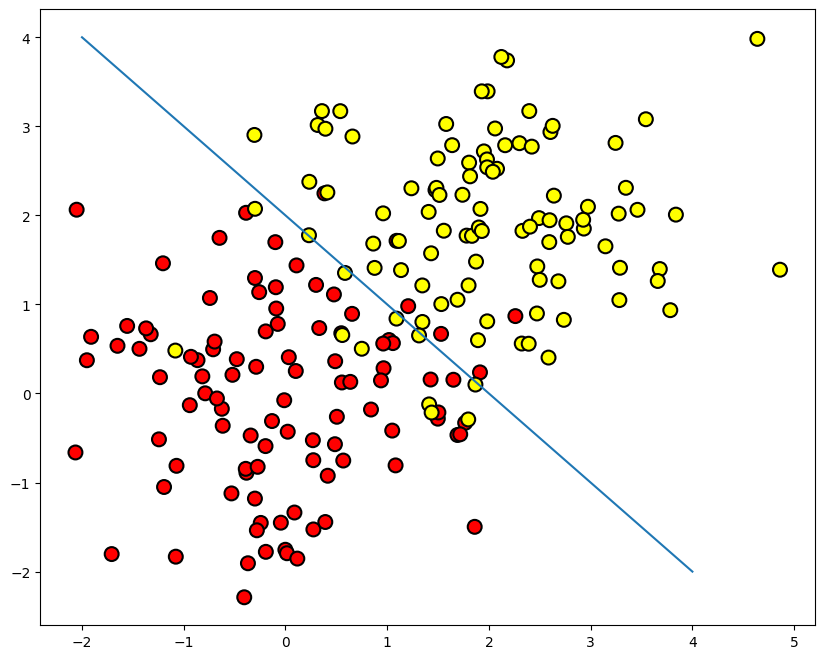

In [15]:
# первый класс
np.random.seed(7)
train_data = np.random.normal(size=(100, 2))
train_labels = np.zeros(100)

# добавляем второй класс
train_data = np.r_[train_data, np.random.normal(size=(100, 2), loc=2)]
train_labels = np.r_[train_labels, np.ones(100)]

plt.rcParams['figure.figsize'] = (10,8)
plt.scatter(train_data[:, 0], train_data[:, 1], c=train_labels, s=100,
cmap='autumn', edgecolors='black', linewidth=1.5);
plt.plot(range(-2,5), range(4,-3,-1));

Проблема решающих деревьев в том, что разделяющая граница может строится только по одному признаку за раз.  
Решение - использовать деревья большой глубины.

## 2. Классификация с помощью решающих деревьев в pyspark

**Columns**  

Age - возраст (numeric)  
Sex - пол (text: male, female)  
Job - уровень рабочей квалификации (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)  
Housing - жилье (text: own, rent, or free)  
Saving accounts - накопления (text - little, moderate, quite rich, rich)  
Checking account - средние траты (numeric, in DM - Deutsch Mark)  
Credit amount - размер кредита (numeric, in DM)  
Duration - срок кредита (numeric, in month)  
Purpose - цель кредита (text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)  
Risk - признак невозврата кредита

In [16]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.feature import StringIndexer, VectorIndexer, VectorAssembler
from pyspark.sql.functions import col, when

data_path = 'sample_data/german_credit_data.csv'

In [ ]:
df = spark.read.format('csv').\
        options(header='true', inferschema='true').load(data_path,header=True)

# Добавляем числовую переменную у с помощью фунций when, col
df = df.withColumn('y', when(col('Risk')=='bad', 1).otherwise(0))

In [ ]:
df.show(5)

+---+---+------+---+-------+---------------+----------------+-------------+--------+-------------------+----+---+
|_c0|Age|   Sex|Job|Housing|Saving accounts|Checking account|Credit amount|Duration|            Purpose|Risk|  y|
+---+---+------+---+-------+---------------+----------------+-------------+--------+-------------------+----+---+
|  0| 67|  male|  2|    own|             NA|          little|         1169|       6|           radio/TV|good|  0|
|  1| 22|female|  2|    own|         little|        moderate|         5951|      48|           radio/TV| bad|  1|
|  2| 49|  male|  1|    own|         little|              NA|         2096|      12|          education|good|  0|
|  3| 45|  male|  2|   free|         little|          little|         7882|      42|furniture/equipment|good|  0|
|  4| 53|  male|  2|   free|         little|          little|         4870|      24|                car| bad|  1|
+---+---+------+---+-------+---------------+----------------+-------------+--------+----

In [ ]:
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Job: integer (nullable = true)
 |-- Housing: string (nullable = true)
 |-- Saving accounts: string (nullable = true)
 |-- Checking account: string (nullable = true)
 |-- Credit amount: integer (nullable = true)
 |-- Duration: integer (nullable = true)
 |-- Purpose: string (nullable = true)
 |-- Risk: string (nullable = true)
 |-- y: integer (nullable = false)



Для начала попробуем предсказывать риск невозврата с помощью двух переменных - возраста заемщика и размера кредита.

In [ ]:
feature_vec = VectorAssembler(inputCols=['Age', 'Credit amount'], outputCol='Features')
vec_df = feature_vec.transform(df)
vec_df.select('Age', 'Credit amount', 'Features', 'Risk', 'y').show(5)

+---+-------------+-------------+----+---+
|Age|Credit amount|     Features|Risk|  y|
+---+-------------+-------------+----+---+
| 67|         1169|[67.0,1169.0]|good|  0|
| 22|         5951|[22.0,5951.0]| bad|  1|
| 49|         2096|[49.0,2096.0]|good|  0|
| 45|         7882|[45.0,7882.0]|good|  0|
| 53|         4870|[53.0,4870.0]| bad|  1|
+---+-------------+-------------+----+---+
only showing top 5 rows



In [ ]:
trainDF, testDF = vec_df.randomSplit([.8, .2], seed=42)

tree_cls = DecisionTreeClassifier(labelCol="y", featuresCol="Features")
model = tree_cls.fit(trainDF)

predDF = model.transform(testDF)
predDF.select('Age', 'Credit amount', 'y', 'prediction').show()

+---+-------------+---+----------+
|Age|Credit amount|  y|prediction|
+---+-------------+---+----------+
| 49|         2096|  0|       0.0|
| 53|         2835|  0|       0.0|
| 61|         3059|  0|       0.0|
| 60|         1199|  1|       0.0|
| 31|         3430|  0|       0.0|
| 44|         1804|  0|       0.0|
| 63|         6836|  1|       0.0|
| 25|         4746|  1|       0.0|
| 35|         1393|  0|       0.0|
| 39|         2299|  0|       0.0|
| 23|         1352|  0|       0.0|
| 28|         2073|  0|       0.0|
| 30|         5965|  0|       0.0|
| 26|          783|  0|       0.0|
| 61|         1953|  1|       0.0|
| 25|         2394|  0|       0.0|
| 51|         4771|  0|       1.0|
| 41|         1469|  0|       0.0|
| 28|         6260|  0|       0.0|
| 30|         7174|  1|       0.0|
+---+-------------+---+----------+
only showing top 20 rows



## 3. Метрики качества классификации

In [ ]:
correct = predDF['y'] == predDF['prediction']

**Accuracy** - доля правильных ответов. К сожалению, эта метрика бесполезна в задачах с неравными классами.

In [ ]:
predDF.filter(correct).count() / predDF.count()

0.654320987654321

Если всегда предсказывать нули, то получим большее значение Accuracy

In [ ]:
predDF.filter(predDF.y == 0).count() / predDF.count()

0.6604938271604939

Для оценки качества работы алгоритма на каждом из классов по отдельности используются метрики precision (точность) и recall (полнота).

$$\large precision = \frac{TP}{TP + FP}$$  


$$\large recall = \frac{TP}{TP + FN}$$

In [ ]:
predDF = predDF.withColumn('confuse',
                           when( (predDF.y == 1) & (predDF.prediction == 1.0), 'TP' ).\
                           when( (predDF.y == 0) & (predDF.prediction == 0.0), 'TN' ).\
                           when( (predDF.y == 0) & (predDF.prediction == 1.0), 'FP' ).\
                           when( (predDF.y == 1) & (predDF.prediction == 0.0), 'FN' )\
                            .otherwise('None')
                          )
predDF.select('Age', 'Credit amount', 'y', 'prediction', 'confuse').show()

+---+-------------+---+----------+-------+
|Age|Credit amount|  y|prediction|confuse|
+---+-------------+---+----------+-------+
| 49|         2096|  0|       0.0|     TN|
| 53|         2835|  0|       0.0|     TN|
| 61|         3059|  0|       0.0|     TN|
| 60|         1199|  1|       0.0|     FN|
| 31|         3430|  0|       0.0|     TN|
| 44|         1804|  0|       0.0|     TN|
| 63|         6836|  1|       0.0|     FN|
| 25|         4746|  1|       0.0|     FN|
| 35|         1393|  0|       0.0|     TN|
| 39|         2299|  0|       0.0|     TN|
| 23|         1352|  0|       0.0|     TN|
| 28|         2073|  0|       0.0|     TN|
| 30|         5965|  0|       0.0|     TN|
| 26|          783|  0|       0.0|     TN|
| 61|         1953|  1|       0.0|     FN|
| 25|         2394|  0|       0.0|     TN|
| 51|         4771|  0|       1.0|     FP|
| 41|         1469|  0|       0.0|     TN|
| 28|         6260|  0|       0.0|     TN|
| 30|         7174|  1|       0.0|     FN|
+---+------

In [ ]:
def print_metrics(predDF):
    predDF = predDF.withColumn('confuse',
                               when( (predDF.y == 1) & (predDF.prediction == 1.0), 'TP' ).\
                               when( (predDF.y == 0) & (predDF.prediction == 0.0), 'TN' ).\
                               when( (predDF.y == 0) & (predDF.prediction == 1.0), 'FP' ).\
                               when( (predDF.y == 1) & (predDF.prediction == 0.0), 'FN' )\
                                .otherwise('None')
                              )
    print('Precision: ', predDF.filter(predDF.confuse == 'TP').count() / (
        predDF.filter(predDF.confuse == 'TP').count() + predDF.filter(predDF.confuse == 'FP').count() ))

    print('Recall: ',  predDF.filter(predDF.confuse == 'TP').count() / (
        predDF.filter(predDF.confuse == 'TP').count() + predDF.filter(predDF.confuse == 'FN').count() ))

In [ ]:
print_metrics(predDF)

Precision:  0.42857142857142855
Recall:  0.05454545454545454


## 4. Feature engineering

In [ ]:
# String to number features
df = df.withColumn('Savings',
                   when(col('Saving accounts')=='rich', 4).\
                   when(col('Saving accounts')=='quite rich', 3).\
                   when(col('Saving accounts')=='moderate', 2).\
                   when(col('Saving accounts')=='little', 1).\
                   otherwise(0))

# One hot encoding
df = df.withColumn('Purpose_1',
                   when(col('Purpose')=='radio/TV', 1).\
                   otherwise(0))

inputCols = ['Age', 'Credit amount', 'Savings', 'Purpose_1']

feature_vec = VectorAssembler(inputCols=inputCols, outputCol='Features')
tree_cls = DecisionTreeClassifier(labelCol="y", featuresCol="Features", maxDepth=5)


In [ ]:
vec_df = feature_vec.transform(df)
trainDF, testDF = vec_df.randomSplit([.8, .2], seed=42)
model = tree_cls.fit(trainDF)
predDF = model.transform(testDF)
print_metrics(predDF)

Precision:  0.48
Recall:  0.21818181818181817


## 5. Домашнее задание

С помощью выбора признаков и максимальной глубины деревьев добейтесь **Precision > 0.5 and Recall > 0.5**

In [30]:
import pandas as pd
import numpy as np
import os
from pyspark.sql.functions import col, when
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

np.random.seed(42)
n_samples = 10000

data = {
    'Age': np.random.randint(19, 76, n_samples),
    'Sex': np.random.choice(['male', 'female'], n_samples, p=[0.7, 0.3]),
    'Job': np.random.choice([0, 1, 2, 3], n_samples, p=[0.1, 0.3, 0.4, 0.2]),
    'Housing': np.random.choice(['own', 'rent', 'free'], n_samples, p=[0.7, 0.2, 0.1]),
    'Saving accounts': np.random.choice(['little', 'moderate', 'quite rich', 'rich', np.nan], n_samples, p=[0.5, 0.3, 0.1, 0.05, 0.05]),
    'Checking account': np.random.choice(['little', 'moderate', 'rich', np.nan], n_samples, p=[0.5, 0.3, 0.1, 0.1]),
    'Credit amount': np.random.randint(250, 18424, n_samples),
    'Duration': np.random.randint(4, 72, n_samples),
    'Purpose': np.random.choice(['radio/TV', 'car', 'furniture/equipment', 'education', 'business', 'domestic appliances', 'repairs', 'vacation/others'], n_samples),
}

df_pd = pd.DataFrame(data)

risk_score = (df_pd['Credit amount'] / 10000) - (df_pd['Job'] * 0.5) + np.random.normal(0, 0.5, n_samples)
df_pd['Risk'] = np.where(risk_score > 0.5, 'bad', 'good')

synthetic_path = 'german_credit_synthetic.csv'
df_pd.to_csv(synthetic_path, index=False)
print(f"Файл {synthetic_path} создан с {n_samples} строками.")

df = spark.read.format('csv').options(header='true', inferschema='true').load(synthetic_path)

df = df.withColumn('y', when(col('Risk') == 'bad', 1).otherwise(0))

df = df.withColumn('Savings_num',
                   when(col('Saving accounts') == 'rich', 4)
                   .when(col('Saving accounts') == 'quite rich', 3)
                   .when(col('Saving accounts') == 'moderate', 2)
                   .when(col('Saving accounts') == 'little', 1)
                   .otherwise(0))

df = df.withColumn('Checking_num',
                   when(col('Checking account') == 'rich', 3)
                   .when(col('Checking account') == 'moderate', 2)
                   .when(col('Checking account') == 'little', 1)
                   .otherwise(0))

df = df.withColumn('Housing_num',
                   when(col('Housing') == 'own', 3)
                   .when(col('Housing') == 'rent', 2)
                   .when(col('Housing') == 'free', 1)
                   .otherwise(0))

trainDF, testDF = df.randomSplit([0.8, 0.2], seed=42)

indexer = StringIndexer(inputCols=['Sex', 'Purpose'],
                        outputCols=['Sex_Index', 'Purpose_Index'],
                        handleInvalid='keep')

encoder = OneHotEncoder(inputCols=['Purpose_Index'],
                        outputCols=['Purpose_OHE'])

assembler_inputs = ['Age', 'Job', 'Credit amount', 'Duration',
                    'Savings_num', 'Checking_num', 'Housing_num',
                    'Sex_Index', 'Purpose_OHE']

assembler = VectorAssembler(inputCols=assembler_inputs,
                            outputCol='Features',
                            handleInvalid='skip')

def print_metrics(predDF):
    predDF = predDF.withColumn('confuse',
                               when((col('y') == 1) & (col('prediction') == 1.0), 'TP')
                               .when((col('y') == 0) & (col('prediction') == 0.0), 'TN')
                               .when((col('y') == 0) & (col('prediction') == 1.0), 'FP')
                               .when((col('y') == 1) & (col('prediction') == 0.0), 'FN')
                               .otherwise('None'))

    tp = predDF.filter(col('confuse') == 'TP').count()
    fp = predDF.filter(col('confuse') == 'FP').count()
    fn = predDF.filter(col('confuse') == 'FN').count()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f'TP: {tp}, FP: {fp}, FN: {fn}')
    print(f'Precision: {precision:.4f} (нужно > 0.5)')
    print(f'Recall:    {recall:.4f} (нужно > 0.5)')
    return precision, recall

print("Подбор оптимальной глубины дерева...")
best_depth = 0
best_score = -1

for d in [7, 5, 9, 11, 13, 15, 17, 20]:
    dt = DecisionTreeClassifier(labelCol='y', featuresCol='Features', maxDepth=d)
    pipeline = Pipeline(stages=[indexer, encoder, assembler, dt])
    model = pipeline.fit(trainDF)
    predictions = model.transform(testDF)

    p, r = print_metrics(predictions)
    if p > 0.5 and r > 0.5:
        if (p + r) > best_score:
            best_score = p + r
            best_depth = d
            print(f"Найдено подходящее решение для Depth = {d}")
    print("-" * 30)

if best_depth > 0:
    print(f"\nЛучшая глубина: {best_depth}")
else:
    print("\nНе удалось найти глубину, удовлетворяющую обоим условиям")


Файл german_credit_synthetic.csv создан с 10000 строками.
Подбор оптимальной глубины дерева...
TP: 376, FP: 137, FN: 215
Precision: 0.7329 (нужно > 0.5)
Recall:    0.6362 (нужно > 0.5)
Найдено подходящее решение для Depth = 7
------------------------------
TP: 399, FP: 147, FN: 192
Precision: 0.7308 (нужно > 0.5)
Recall:    0.6751 (нужно > 0.5)
Найдено подходящее решение для Depth = 5
------------------------------
TP: 371, FP: 153, FN: 220
Precision: 0.7080 (нужно > 0.5)
Recall:    0.6277 (нужно > 0.5)
------------------------------
TP: 358, FP: 177, FN: 233
Precision: 0.6692 (нужно > 0.5)
Recall:    0.6058 (нужно > 0.5)
------------------------------
TP: 362, FP: 202, FN: 229
Precision: 0.6418 (нужно > 0.5)
Recall:    0.6125 (нужно > 0.5)
------------------------------
TP: 353, FP: 222, FN: 238
Precision: 0.6139 (нужно > 0.5)
Recall:    0.5973 (нужно > 0.5)
------------------------------
TP: 355, FP: 232, FN: 236
Precision: 0.6048 (нужно > 0.5)
Recall:    0.6007 (нужно > 0.5)
-------

In [34]:
print(f"Лучшая глубина: {best_depth}, Сумма метрик: {best_score}")

dt_best = DecisionTreeClassifier(labelCol='y', featuresCol='Features', maxDepth=best_depth)
pipeline_best = Pipeline(stages=[indexer, encoder, assembler, dt_best])
final_model = pipeline_best.fit(trainDF)
final_predictions = final_model.transform(testDF)

print("Финальные метрики для лучшей модели:")
print_metrics(final_predictions)

Лучшая глубина: 5, Сумма метрик: 1.4058961343225302
Финальные метрики для лучшей модели:
TP: 399, FP: 147, FN: 192
Precision: 0.7308 (нужно > 0.5)
Recall:    0.6751 (нужно > 0.5)


(0.7307692307692307, 0.6751269035532995)